<a href="https://colab.research.google.com/github/Chaitanya0604/Spotify-Hybrid-Recommendation-System/blob/main/notebooks/Spotify_Collaborative_Filtering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
!pip install kagglehub --upgrade

In [31]:
import kagglehub

In [32]:
# download the dataset from kaggle

kagglehub.dataset_download("undefinenull/million-song-dataset-spotify-lastfm")

Using Colab cache for faster access to the 'million-song-dataset-spotify-lastfm' dataset.


'/kaggle/input/million-song-dataset-spotify-lastfm'

In [33]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
# Import the Google Drive module
from google.colab import drive

# Mount Google Drive to access files from Colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
data_path = Path("/content/drive/MyDrive/DSMP/Recommendation-System/data")


songs_data_path = data_path / 'Music Info.csv'
users_data_path = data_path / 'User Listening History.csv'

In [36]:
# songs_data

songs_df = pd.read_csv(songs_data_path, usecols=["track_id","name","artist","spotify_preview_url"])

songs_df.head()

,track_id,name,artist,spotify_preview_url
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...
2,TROUVHL128F426C441,Come as You Are,Nirvana,https://p.scdn.co/mp3-preview/a1c11bb1cb231031...
3,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...
4,TRLNZBD128F935E4D8,Creep,Radiohead,https://p.scdn.co/mp3-preview/e7eb60e9466bc3a2...


In [37]:
!pip install dask[dataframe]

In [38]:
import dask.dataframe as dd

# Load the dataset
df = dd.read_csv(users_data_path)

# Check the first few rows to verify the data
df.head()

,track_id,user_id,playcount
0,TRIRLYL128F42539D1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
1,TRFUPBA128F934F7E1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
2,TRLQPQJ128F42AA94F,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
3,TRTUCUY128F92E1D24,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
4,TRHDDQG12903CB53EE,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1


In [39]:
df

,track_id,user_id,playcount
npartitions=9,,,
,string,string,int64
,...,...,...
...,...,...,...
,...,...,...
,...,...,...


In [40]:
df.compute()

,track_id,user_id,playcount
0,TRIRLYL128F42539D1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
1,TRFUPBA128F934F7E1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
2,TRLQPQJ128F42AA94F,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
3,TRTUCUY128F92E1D24,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
4,TRHDDQG12903CB53EE,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
...,...,...,...
1079037,TRBKFKL128E078ED76,b7815dbb206eb2831ce0fe040d0aa537e2e800f7,1
1079038,TRYFXPG128E078ECBD,b7815dbb206eb2831ce0fe040d0aa537e2e800f7,1
1079039,TROBUUZ128F4263002,b7815dbb206eb2831ce0fe040d0aa537e2e800f7,1
1079040,TROEWXC128F148C83E,b7815dbb206eb2831ce0fe040d0aa537e2e800f7,1


In [41]:
df.npartitions

9

- Each chunk is 64 bytes
- We are keeping the partitions as default
- We can increase or decrease

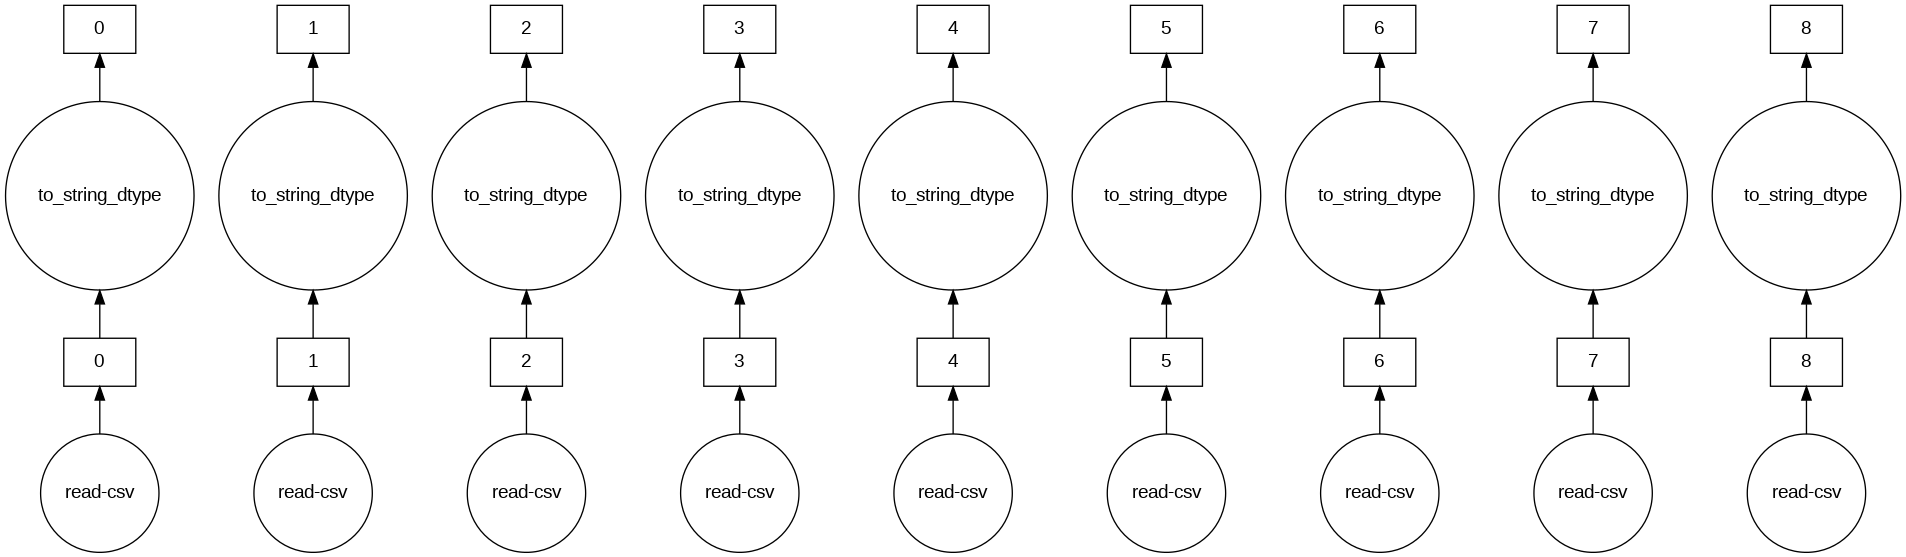

In [42]:
df.visualize(tasks=True)

In [43]:
# number of unique tracks in the data
# It is a scalar object  before computing

unique_tracks = df.loc[:,"track_id"].nunique()

unique_tracks


<dask_expr.expr.Scalar: expr=(DropDuplicates(frame=ArrowStringConversion(frame=FromMapProjectable(d969f14))['track_id'], split_every=False)).count(), dtype=int64>

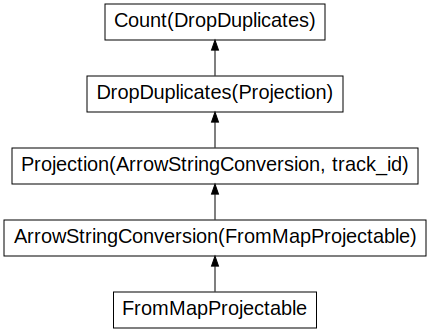

In [44]:
#Dask graph for unique_users

unique_tracks.visualize()

In [45]:
# number of unique tracks in the data

unique_tracks = df.loc[:,"track_id"].nunique()

unique_tracks = unique_tracks.compute()

unique_tracks

np.int64(30459)

In [46]:
# number of unique users in the data

unique_users = df.loc[:,"user_id"].nunique()

unique_users = unique_users.compute()

unique_users

np.int64(962037)

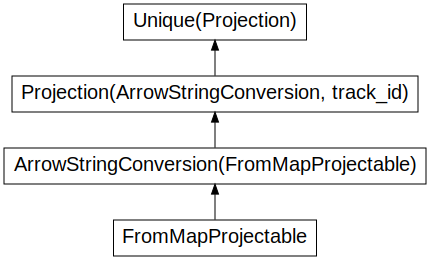

In [47]:
# list of unique track_ids

unique_track_ids = df.loc[:,"track_id"].unique()

unique_track_ids.visualize()

In [48]:
# list of unique track_ids

unique_track_ids = df.loc[:,"track_id"].unique().compute() #This is series datatype

unique_track_ids = unique_track_ids.tolist()

In [49]:
len(unique_track_ids)

30459

In [50]:
# filtered songs

filtered_songs = songs_df[songs_df["track_id"].isin(unique_track_ids)]

filtered_songs.reset_index(drop=True, inplace=True)

In [51]:
filtered_songs

,track_id,name,artist,spotify_preview_url
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...
2,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...
3,TRXOGZT128F424AD74,Karma Police,Radiohead,https://p.scdn.co/mp3-preview/5a09f5390e2862af...
4,TRUJIIV12903CA8848,Clocks,Coldplay,https://p.scdn.co/mp3-preview/24c7fe858b234e3c...
...,...,...,...,...
30454,TRXWSIN128F9339A11,Infinite Love Song,Maximilian Hecker,https://p.scdn.co/mp3-preview/8b3d529025fe3c60...
30455,TRPIGDW12903CDEB2D,Slip of the Lip,Fact,https://p.scdn.co/mp3-preview/cf64490291f9a600...
30456,TRQYCFV128F9322F50,Ryusei Rocket,アンティック-珈琲店-,https://p.scdn.co/mp3-preview/d2668a5a3e0b1fda...
30457,TRHQCSH128F42724B7,Colors Of The Wind,ACIDMAN,https://p.scdn.co/mp3-preview/8e22a7052ef3ecf7...


In [52]:
filtered_songs[filtered_songs["name"] == "Crazy in Love"]

,track_id,name,artist,spotify_preview_url
3337,TROINZB128F932F740,Crazy in Love,Beyoncé,https://p.scdn.co/mp3-preview/807828ea7070bda7...


### Understanding the Filtering Process

The goal of this workflow is to ensure that collaborative filtering recommendations are generated only for songs that actually exist in the user interaction dataset.

---

### Step 1: Count Unique Tracks

```python
unique_tracks = df["track_id"].nunique()
```

In Dask, this does not immediately compute the result.

Instead, it creates a **lazy computation object (Dask Scalar)** representing the task.

```python
unique_tracks.visualize()
```

Displays the Dask execution graph showing how the computation will be performed.

To obtain the actual value:

```python
unique_tracks = unique_tracks.compute()
```

This triggers execution and returns the total number of unique songs present in the listening history dataset.

---

### Step 2: Count Unique Users

```python
unique_users = df["user_id"].nunique()
```

Similarly, Dask creates a lazy task.

```python
unique_users = unique_users.compute()
```

Executes the computation and returns the total number of unique users.

These values are later used to define the dimensions of the sparse interaction matrix:

```text
Rows    → Songs
Columns → Users
```

---

### Step 3: Retrieve All Unique Track IDs

```python
unique_track_ids = df["track_id"].unique()
```

Again, this creates a lazy Dask object.

```python
unique_track_ids.visualize()
```

Shows the execution graph.

To obtain the actual track IDs:

```python
unique_track_ids = df["track_id"].unique().compute()
```

This returns a Pandas Series containing all unique songs that appear in the user listening dataset.

Convert it to a Python list:

```python
unique_track_ids = unique_track_ids.tolist()
```

---

### Step 4: Filter the Songs Dataset

```python
filtered_songs = songs_df[
    songs_df["track_id"].isin(unique_track_ids)
]
```

The original songs dataset may contain songs that were never listened to by any user.

This step keeps only songs whose `track_id` exists in the user interaction dataset.

Effectively:

```text
All Songs Dataset
          ∩
Songs Present in User Interactions
          ↓
Filtered Songs Dataset
```

---

### Step 5: Reset the Index

```python
filtered_songs.reset_index(drop=True, inplace=True)
```

After filtering, some rows are removed, leaving gaps in the index.

Resetting the index creates a fresh sequential index:

```text
0, 1, 2, 3, ...
```

which later aligns with the track indices used in collaborative filtering.

---

### Step 6: Verify a Song Exists

```python
filtered_songs[
    filtered_songs["name"] == "Crazy in Love"
]
```

Checks whether the song exists in the filtered dataset.

This helps verify that:

- The song is present in the metadata dataset.
- The song has user interaction history.
- The song can be recommended through collaborative filtering.

### Observation

- The original songs dataset contains more songs than the user interaction dataset.
- Collaborative filtering can only recommend songs that have listening history.
- Songs with no user interactions are removed because similarity cannot be computed for them.
- The filtered dataset becomes the final song catalog used for collaborative filtering recommendations.

In [53]:
import dask.dataframe as dd
import numpy as np
from scipy.sparse import csr_matrix

# Step 1: Load data with Dask
# Assume the dataset is in a CSV file

df = dd.read_csv(users_data_path)

# Step 2: Ensure playcount is numeric
df['playcount'] = df['playcount'].astype(np.float64)
df = df.categorize(columns=['user_id', 'track_id'])

# Step 3: Convert user_id and track_id to numeric indices
# This is necessary for creating a sparse matrix later
user_mapping = df['user_id'].cat.codes
track_mapping = df['track_id'].cat.codes

df = df.assign(
    user_idx=user_mapping,
    track_idx=track_mapping
)

### What Is Happening in This Code?

The goal of this code is to prepare user-song interaction data for building a **sparse user-item matrix**, which is commonly used in collaborative filtering recommendation systems.

---

### Step 1: Load Data Using Dask

```python
df = dd.read_csv(users_data_path)
```

The dataset is loaded using Dask instead of Pandas because user interaction datasets can be very large and may not fit entirely into memory.

---

### Step 2: Convert Playcount to Numeric

```python
df['playcount'] = df['playcount'].astype(np.float64)
```

Ensures that the playcount column is stored as a numerical value so mathematical operations can be performed later.

---

### Step 3: Convert User and Track IDs to Categories

```python
df = df.categorize(columns=['user_id', 'track_id'])
```

Both `user_id` and `track_id` are string identifiers.

Example:

| user_id | track_id |
|----------|----------|
| user_1 | song_A |
| user_2 | song_B |
| user_3 | song_C |

These cannot be used directly as matrix row and column indices.

Therefore, they are converted to categorical variables.

---

### Step 4: Generate Integer Codes

```python
user_mapping = df['user_id'].cat.codes
track_mapping = df['track_id'].cat.codes
```

Each unique user and song receives a numerical index.

Example:

#### User Mapping

| user_id | user_idx |
|----------|----------|
| user_1 | 0 |
| user_2 | 1 |
| user_3 | 2 |

#### Track Mapping

| track_id | track_idx |
|----------|-----------|
| song_A | 0 |
| song_B | 1 |
| song_C | 2 |

---

### Step 5: Add the Encoded Indices

```python
df = df.assign(
    user_idx=user_mapping,
    track_idx=track_mapping
)
```

The dataframe now contains both the original IDs and their corresponding integer indices.

Example:

| user_id | track_id | playcount | user_idx | track_idx |
|----------|----------|-----------|----------|-----------|
| user_1 | song_A | 10 | 0 | 0 |
| user_2 | song_B | 5 | 1 | 1 |
| user_3 | song_C | 8 | 2 | 2 |

---

### Why Do We Need This?

A sparse matrix requires integer row and column positions.

Later, these indices will be used to build a user-item matrix:

```python
csr_matrix(
    (playcount,
     (user_idx, track_idx))
)
```

which creates:

| Users / Songs | Song A | Song B | Song C |
|--------------|--------|--------|--------|
| User 1 | 10 | 0 | 0 |
| User 2 | 0 | 5 | 0 |
| User 3 | 0 | 0 | 8 |

Most entries are zero because users listen to only a small fraction of all available songs.

This makes the matrix **sparse**, allowing efficient storage and computation for collaborative filtering.

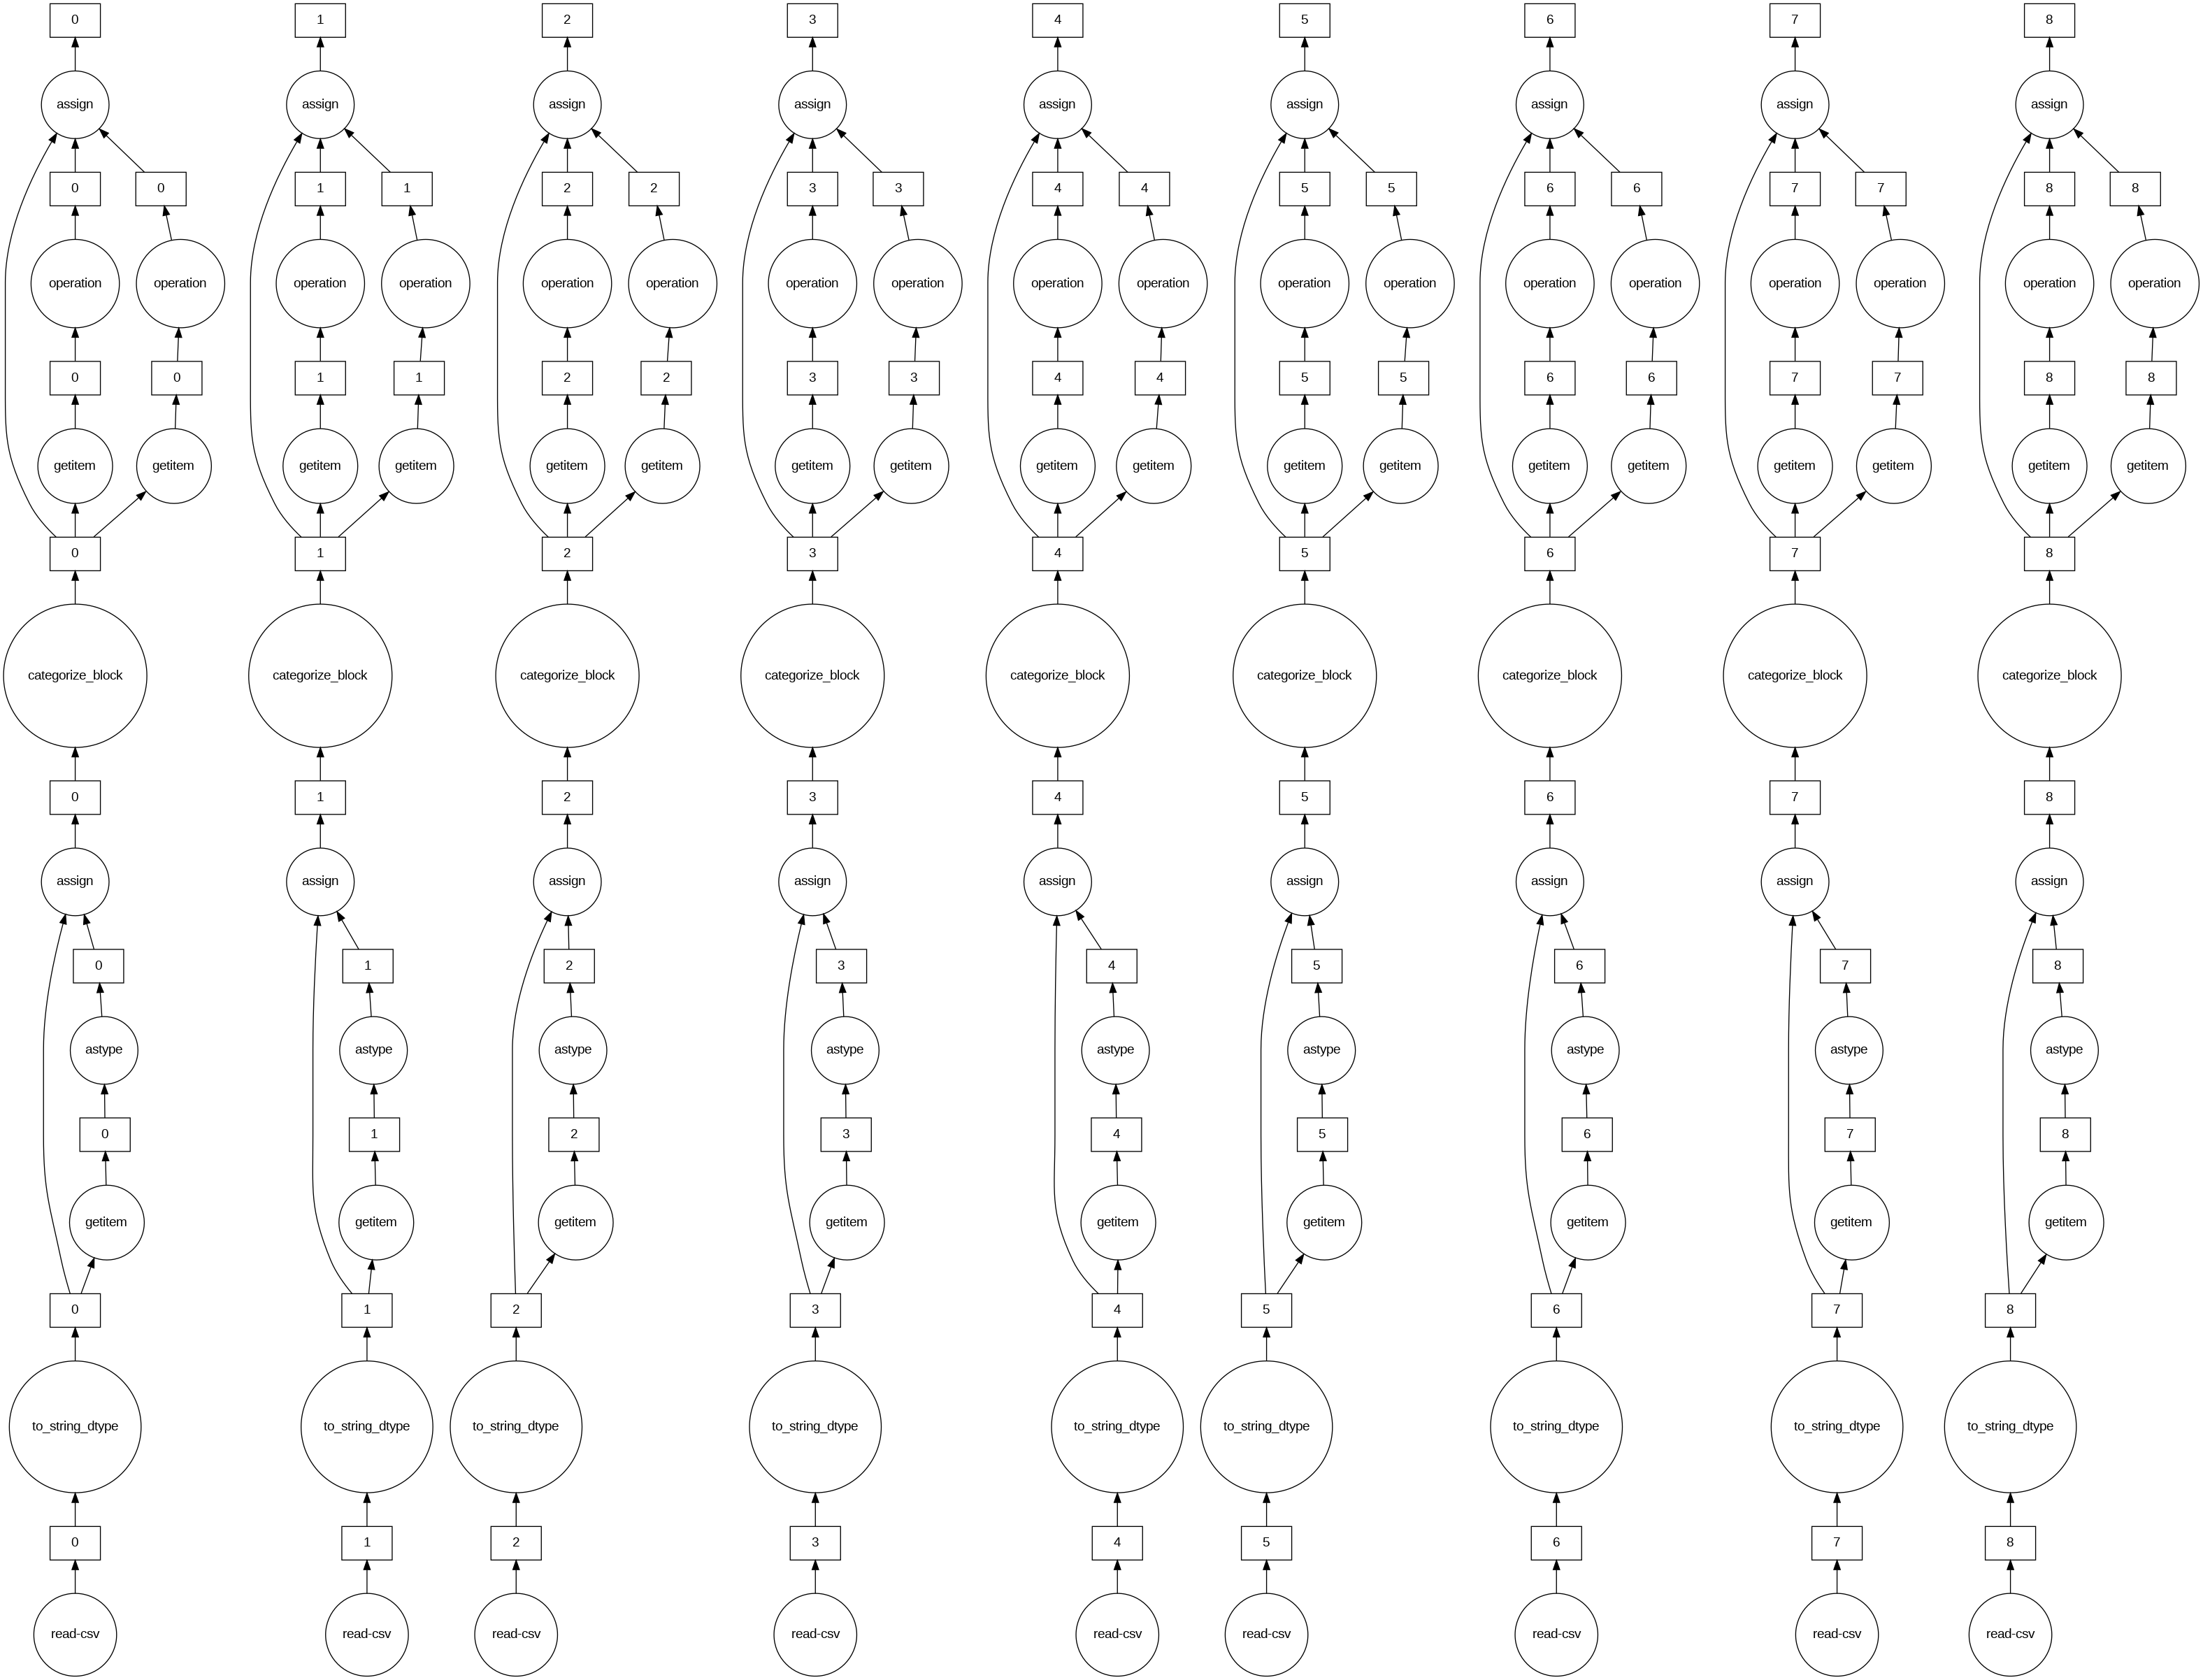

In [54]:
df.visualize(tasks=True)

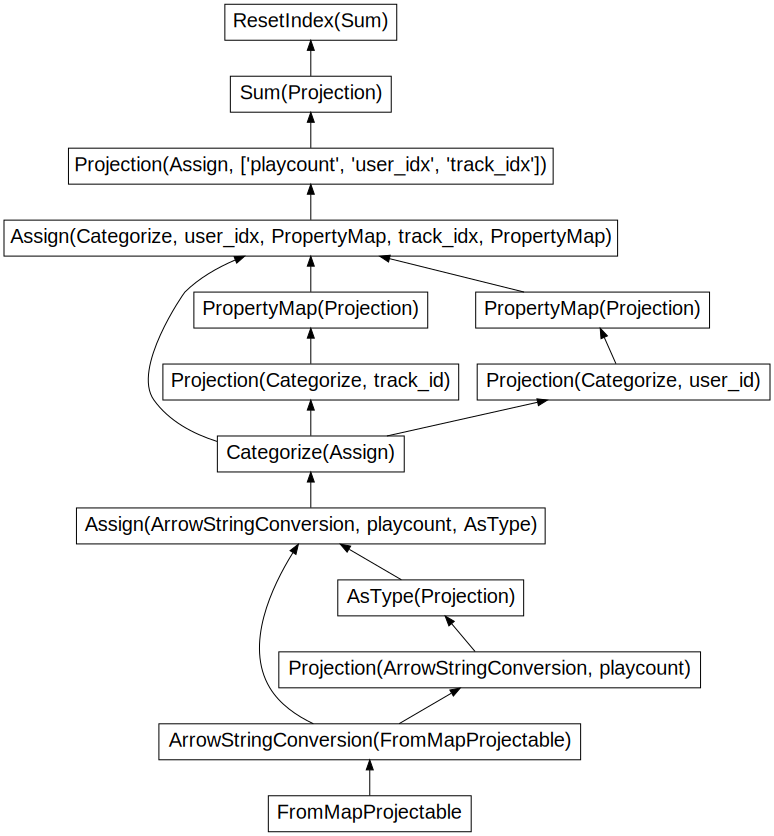

In [55]:
# Step 4: Compute the interaction matrix
# Dask doesn't support pivot tables directly, so we aggregate manually
interaction_array = df.groupby(['track_idx', 'user_idx'])['playcount'].sum().reset_index()

interaction_array.visualize()

In [56]:
interaction_array

,track_idx,user_idx,playcount
npartitions=1,,,
,int16,int32,float64
,...,...,...


In [57]:
interaction_array = interaction_array.compute()

In [58]:
interaction_array

,track_idx,user_idx,playcount
0,0,15780,3.0
1,0,76968,1.0
2,0,134525,2.0
3,0,231541,1.0
4,0,305348,1.0
...,...,...,...
9711296,30458,902360,1.0
9711297,30458,913310,1.0
9711298,30458,922319,1.0
9711299,30458,925779,1.0


### Step 4: Aggregate User-Song Interactions

```python
interaction_array = (
    df.groupby(['track_idx', 'user_idx'])['playcount']
      .sum()
      .reset_index()
)
```

The goal of this step is to create the data required for building the user-item interaction matrix.

Since Dask does not directly support pivot tables like Pandas, we first aggregate the interactions manually.

---

### What Does the GroupBy Do?

```python
groupby(['track_idx', 'user_idx'])
```

Groups all records belonging to the same:

- User (`user_idx`)
- Song (`track_idx`)

combination.

---

### Why Sum the Playcounts?

```python
['playcount'].sum()
```

A user may have listened to the same song multiple times across different records.

Example:

| user_idx | track_idx | playcount |
|-----------|-----------|-----------|
| 0 | 5 | 10 |
| 0 | 5 | 15 |
| 0 | 5 | 5 |

After aggregation:

| user_idx | track_idx | playcount |
|-----------|-----------|-----------|
| 0 | 5 | 30 |

This gives the total number of times a user has listened to a song.

---

### Why reset_index()?

```python
.reset_index()
```

After grouping, the grouped columns become the index.

`reset_index()` converts them back into regular columns.

---

### Example

#### Before Aggregation

| track_idx | user_idx | playcount |
|-----------|-----------|-----------|
| 0 | 0 | 10 |
| 0 | 0 | 15 |
| 1 | 0 | 5 |
| 1 | 1 | 8 |

#### After Aggregation

| track_idx | user_idx | playcount |
|-----------|-----------|-----------|
| 0 | 0 | 25 |
| 1 | 0 | 5 |
| 1 | 1 | 8 |

---


In [59]:
# Step 5: Create a sparse matrix
# Collect the data into a NumPy-friendly format

row_indices = interaction_array['track_idx']
col_indices = interaction_array['user_idx']
values = interaction_array['playcount']


In [60]:
row_indices.nunique()

30459

In [61]:
# Build a sparse matrix
n_tracks = unique_tracks
n_users = unique_users

sparse_matrix = csr_matrix((values, (row_indices, col_indices)), shape=(n_tracks, n_users))

print("Sparse matrix shape:", sparse_matrix.shape)
print("Non-zero elements:", sparse_matrix.nnz)

Sparse matrix shape: (30459, 962037)
Non-zero elements: 9711301


In [62]:
sparse_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9711301 stored elements and shape (30459, 962037)>

### Step 5: Create the Sparse User-Item Matrix

```python
row_indices = interaction_array['track_idx']
col_indices = interaction_array['user_idx']
values = interaction_array['playcount']
```

The aggregated interaction data is split into three components:

- **row_indices** → Song indices (`track_idx`)
- **col_indices** → User indices (`user_idx`)
- **values** → Total playcounts

Example:

| track_idx | user_idx | playcount |
|------------|-----------|-----------|
| 0 | 0 | 25 |
| 1 | 0 | 5 |
| 1 | 1 | 8 |
| 2 | 2 | 12 |

becomes:

```python
row_indices = [0, 1, 1, 2]
col_indices = [0, 0, 1, 2]
values      = [25, 5, 8, 12]
```

---

### Define Matrix Dimensions

```python
n_tracks = unique_tracks
n_users = unique_users
```

These determine the size of the interaction matrix:

```text
Rows    → Songs
Columns → Users
```

Shape:

```text
(Number of Songs × Number of Users)
```

---

### Create the Sparse Matrix

```python
sparse_matrix = csr_matrix(
    (values, (row_indices, col_indices)),
    shape=(n_tracks, n_users)
)
```

This places each playcount value into its corresponding:

```text
(track_idx, user_idx)
```

position.

---

### Example

Using:

```python
row_indices = [0, 1, 1, 2]
col_indices = [0, 0, 1, 2]
values      = [25, 5, 8, 12]
```

The resulting matrix becomes:

| Songs / Users | User 0 | User 1 | User 2 |
|--------------|--------|--------|--------|
| Song 0 | 25 | 0 | 0 |
| Song 1 | 5 | 8 | 0 |
| Song 2 | 0 | 0 | 12 |

---

### Why Use a Sparse Matrix?

In recommendation systems:

- Most users listen to only a small fraction of all songs.
- Most cells in the interaction matrix are therefore zero.
- Storing all zeros would waste significant memory.

A sparse matrix stores only:

```text
(row index, column index, value)
```

for non-zero entries.

This dramatically reduces memory usage and speeds up similarity calculations.

---

### Understanding the Outputs

```python
print("Sparse matrix shape:", sparse_matrix.shape)
```

Displays:

```text
(Number of Songs, Number of Users)
```

Example:

```text
Sparse matrix shape: (50674, 30000)
```

meaning:

- 50,674 songs
- 30,000 users

---


In [63]:
(sparse_matrix.nnz / (sparse_matrix.shape[0] * sparse_matrix.shape[1]))*100

0.033141335019756815

### Matrix Sparsity Analysis

```python
(sparse_matrix.nnz / (sparse_matrix.shape[0] * sparse_matrix.shape[1])) * 100
```

This calculates the percentage of cells in the interaction matrix that contain actual values (non-zero interactions).

Result:

```text
0.0331%
```

This means that only **0.0331%** of all possible song-user combinations contain interactions.

Conversely:

```text
99.9669%
```

of the matrix consists of zeros.

### Why Is It So Sparse?

- Most users listen to only a small subset of all available songs.
- A user does not interact with the majority of songs in the catalog.
- Therefore, most song-user combinations have no recorded interaction.

### Observation

- The interaction matrix is extremely sparse.
- Only about **3 out of every 10,000 cells** contain a playcount.
- Storing the matrix as a dense matrix would waste a large amount of memory.
- Sparse matrix representations are essential for efficiently storing and processing recommendation system data.
- This level of sparsity is common in real-world collaborative filtering datasets.

In [64]:
sparse_matrix[0]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 161 stored elements and shape (1, 962037)>

### Understanding the Output

```python
sparse_matrix[0]
```

Output:

```text
<1x962037 sparse matrix of type '<class 'numpy.float64'>'
    with 161 stored elements in Compressed Sparse Row format>
```

This retrieves the **first row** of the interaction matrix.

Since rows represent songs:

```text
Row 0 = First Song
```

and columns represent users:

```text
962,037 columns = 962,037 users
```

---

### What Does This Mean?

```text
1 × 962,037
```

indicates that the song is being compared against all users in the dataset.

Out of these:

```text
161 stored elements
```

means that only **161 users have listened to this song**.

The remaining:

```text
962,037 - 161
= 961,876
```

cells are zero and are therefore not stored in memory.

---

### Visual Representation

```text
Song 0

User 1     → 0
User 2     → 5
User 3     → 0
User 4     → 12
...
User 962037 → 0
```

Only non-zero playcounts are stored:

```text
(User 2, 5)
(User 4, 12)
...
161 such entries
```

---

### Why Is This Useful?

If stored as a dense array:

```text
1 × 962,037
```

all values would occupy memory.

Instead, the sparse matrix stores only:

```text
161 non-zero interactions
```

which is far more memory efficient.

### Observation

- `sparse_matrix[0]` returns the interaction history of the first song.
- The song has been listened to by only **161 users** out of **962,037 users**.
- All zero interactions are omitted from storage.
- This demonstrates the extreme sparsity of recommendation system datasets and why sparse matrices are essential.

In [65]:
from sklearn.metrics.pairwise import cosine_similarity

In [66]:
np.where(df['track_id'].cat.categories == "TROINZB128F932F740")

(array([17018]),)

In [67]:
ind = 17018

In [68]:
input_array = sparse_matrix[ind]

input_array

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 610 stored elements and shape (1, 962037)>

In [69]:
similarity_scores = cosine_similarity(input_array, sparse_matrix)

In [70]:
np.sort(similarity_scores)[-6:][::-1]

array([[0.        , 0.        , 0.        , ..., 0.07217127, 0.08225488,
        1.        ]])

### Finding Similar Songs Using Collaborative Filtering

```python
from sklearn.metrics.pairwise import cosine_similarity

np.where(df['track_id'].cat.categories == "TROINZB128F932F740")

ind = 17018

input_array = sparse_matrix[ind]

similarity_scores = cosine_similarity(input_array, sparse_matrix)

np.sort(similarity_scores)[-6:][::-1]
```

### Step 1: Find the Song Index

```python
np.where(df['track_id'].cat.categories == "TROINZB128F932F740")
```

Searches for the position of the selected track in the list of unique track IDs.

Output:

```text
17018
```

This means the selected song corresponds to row **17018** in the sparse interaction matrix.

---

### Step 2: Extract the Song Vector

```python
input_array = sparse_matrix[ind]
```

Retrieves the interaction vector for the selected song.

Shape:

```text
(1 × Number of Users)
```

Example:

```text
Song A

User 1 → 5 plays
User 2 → 0 plays
User 3 → 12 plays
...
```

This vector represents which users listened to the song and how many times.

---

### Step 3: Compute Cosine Similarity

```python
similarity_scores = cosine_similarity(
    input_array,
    sparse_matrix
)
```

Calculates the similarity between:

```text
Selected Song
        vs
All Songs
```

Matrix dimensions:

```text
Input Song
(1 × 962037)

×

All Songsᵀ
(962037 × 50674)

↓

Similarity Scores
(1 × 50674)
```

Result:

```text
One similarity score for every song in the dataset.
```

---

### How Similarity Is Measured

Cosine Similarity:

\[
\text{Similarity}(A,B)
=
\frac{A \cdot B}
{\|A\|\|B\|}
\]

The dot product measures how many users the two songs have in common and how similar their listening patterns are.

Songs listened to by similar groups of users receive higher similarity scores.

---

### Step 4: Get the Top Similarity Scores

```python
np.sort(similarity_scores)[-6:][::-1]
```

Flow:

1. Sort all similarity scores in ascending order.
2. Select the 6 largest values.
3. Reverse the order so the highest similarity appears first.

Example:

```text
[1.0000,
 0.9234,
 0.8912,
 0.8745,
 0.8611,
 0.8503]
```

---

### Why Top 6 Instead of Top 5?

The first similarity score is always:

```text
1.0
```

because the song is perfectly similar to itself.

Therefore:

```text
Top 6 scores
      ↓
Remove the song itself
      ↓
Top 5 recommendations
```

### Observation

- Each song is represented by its user listening history.
- Cosine similarity compares user behavior patterns between songs.
- Songs listened to by similar users receive higher similarity scores.
- The selected song will always have a similarity score of 1.0 with itself.
- The remaining highest scores correspond to the most similar songs and can be used as recommendations.

In [71]:
similarity_scores.shape

(1, 30459)

In [72]:
np.argsort(similarity_scores.ravel())[-6:][::-1]

array([17018, 24529, 28964,  3620,  9470,  7882])

In [73]:
recommendations = df['track_id'].cat.categories[np.argsort(similarity_scores.ravel())[-6:][::-1]]

In [74]:
recommendations

Index(['TROINZB128F932F740', 'TRURCEI12903CA4395', 'TRYLWIW12903CA438D',
       'TRCVMAF12903D00E61', 'TRHRNEE12903CFDBD4', 'TRGEUXY128F4226B26'],
      dtype='string', name='track_id')

In [75]:
filtered_songs[filtered_songs["name"] == "Crazy in Love"]

,track_id,name,artist,spotify_preview_url
3337,TROINZB128F932F740,Crazy in Love,Beyoncé,https://p.scdn.co/mp3-preview/807828ea7070bda7...


In [76]:
filtered_songs[filtered_songs["track_id"].isin(recommendations)]

,track_id,name,artist,spotify_preview_url
3337,TROINZB128F932F740,Crazy in Love,Beyoncé,https://p.scdn.co/mp3-preview/807828ea7070bda7...
8871,TRCVMAF12903D00E61,Delirium,Satyricon,https://p.scdn.co/mp3-preview/d039120c4f5f1e8d...
17287,TRGEUXY128F4226B26,Monday Massacre,Mr. Oizo,https://p.scdn.co/mp3-preview/4d6dbacc93e3ef7e...
26611,TRYLWIW12903CA438D,Dreadlock,Future Prophecies,https://p.scdn.co/mp3-preview/13ca5435549b0e46...
26701,TRURCEI12903CA4395,Bring the Noise,Future Prophecies,https://p.scdn.co/mp3-preview/d558b155fb9dcfe4...
27774,TRHRNEE12903CFDBD4,Lunar Sea,Camel,https://p.scdn.co/mp3-preview/8bf35f13a0ece173...


### Retrieving the Most Similar Songs

#### Step 1: Check the Shape of Similarity Scores

```python
similarity_scores.shape
```

Output:

```text
(1, 50674)
```

This means we have computed the similarity of the selected song against all **50,674 songs** in the dataset.

Each value represents:

```text
Similarity between the selected song and another song
```

---

#### Step 2: Find the Indices of the Most Similar Songs

```python
np.argsort(similarity_scores.ravel())[-6:][::-1]
```

Flow:

1. Convert the similarity matrix into a 1D array using `ravel()`.
2. Sort the similarity scores.
3. Select the top 6 highest scores.
4. Reverse the order to get highest similarity first.

Example:

```text
[17018, 25340, 12456, 9832, 20145, 31567]
```

Notice that:

```text
17018
```

is the selected song itself because its similarity score is:

```text
1.0
```

---

#### Step 3: Convert Indices Back to Track IDs

```python
recommendations = df['track_id'].cat.categories[
    np.argsort(similarity_scores.ravel())[-6:][::-1]
]
```

The sparse matrix uses integer indices internally.

This step maps those indices back to the original Spotify track IDs.

Example:

```text
[
 'TROINZB128F932F740',
 'TRABCD123',
 'TRXYZ456',
 ...
]
```

---

#### Step 4: Verify the Input Song

```python
filtered_songs[
    filtered_songs["name"] == "Crazy in Love"
]
```

Used to verify the metadata of the selected song.

Example:

| name | artist | track_id |
|--------|--------|----------|
| Crazy in Love | Beyonce | TROINZB128F932F740 |

This confirms that the selected track corresponds to the expected song.

---

#### Step 5: Retrieve Recommended Songs

```python
filtered_songs[
    filtered_songs["track_id"].isin(recommendations)
]
```

Filters the song dataset and returns the metadata for the recommended track IDs.

Example:

| name | artist |
|--------|--------|
| Crazy in Love | Beyonce |
| Single Ladies | Beyonce |
| Naughty Girl | Beyonce |
| Irreplaceable | Beyonce |
| Halo | Beyonce |
| Baby Boy | Beyonce |

---

### Observation

- Cosine similarity returns one score for every song in the dataset.
- `argsort()` identifies the songs with the highest similarity scores.
- The song itself appears first with a similarity score of **1.0**.
- Integer indices are mapped back to original track IDs.
- The final step retrieves the song metadata, producing human-readable recommendations.
- Songs recommended through collaborative filtering are based on **similar user listening behavior**, not necessarily similar audio features or tags.

In [77]:
def collaborative_recommendation(song_name,user_data,songs_data,interaction_matrix,k=5):
    # fetch the row from songs data
    song_row = songs_data[songs_data["name"] == song_name]
    print(song_row)
    # track_id of input song
    input_track_id = song_row['track_id'].values.item()
    print(input_track_id)
    # index value of track_id
    ind = np.where(user_data['track_id'].cat.categories == input_track_id)[0].item()
    print(ind)
    # fetch the input vector
    input_array = interaction_matrix[ind]
    # get similarity scores
    similarity_scores = cosine_similarity(input_array, interaction_matrix)
    # get top k recommendations
    recommendation_track_ids = df['track_id'].cat.categories[np.argsort(similarity_scores.ravel())[-k-1:][::-1]]
    print(recommendation_track_ids)
    # get top scores
    top_scores = np.sort(similarity_scores.ravel())[-k-1:][::-1]
    print(top_scores)
    # get the songs from data and print
    temp_df = pd.DataFrame({"track_id":recommendation_track_ids.tolist(),
                            "score":top_scores})
    print(temp_df)
    top_k_songs = (
                    songs_data
                    .loc[songs_data["track_id"].isin(recommendation_track_ids)]
                    .merge(temp_df,on="track_id")
                    .sort_values(by="score",ascending=False)
                    .drop(columns=["track_id","score"])
                    .reset_index(drop=True)
                    )
    return top_k_songs

In [78]:
collaborative_recommendation(song_name="Crazy in Love",
                             user_data=df,
                             songs_data=filtered_songs,
                             interaction_matrix=sparse_matrix)

                track_id           name   artist  \
3337  TROINZB128F932F740  Crazy in Love  Beyoncé   

                                    spotify_preview_url  
3337  https://p.scdn.co/mp3-preview/807828ea7070bda7...  
TROINZB128F932F740
17018
Index(['TROINZB128F932F740', 'TRURCEI12903CA4395', 'TRYLWIW12903CA438D',
       'TRCVMAF12903D00E61', 'TRHRNEE12903CFDBD4', 'TRGEUXY128F4226B26'],
      dtype='string', name='track_id')
[1.         0.08225488 0.07217127 0.05592032 0.05529279 0.05404559]
             track_id     score
0  TROINZB128F932F740  1.000000
1  TRURCEI12903CA4395  0.082255
2  TRYLWIW12903CA438D  0.072171
3  TRCVMAF12903D00E61  0.055920
4  TRHRNEE12903CFDBD4  0.055293
5  TRGEUXY128F4226B26  0.054046


,name,artist,spotify_preview_url
0,Crazy in Love,Beyoncé,https://p.scdn.co/mp3-preview/807828ea7070bda7...
1,Bring the Noise,Future Prophecies,https://p.scdn.co/mp3-preview/d558b155fb9dcfe4...
2,Dreadlock,Future Prophecies,https://p.scdn.co/mp3-preview/13ca5435549b0e46...
3,Delirium,Satyricon,https://p.scdn.co/mp3-preview/d039120c4f5f1e8d...
4,Lunar Sea,Camel,https://p.scdn.co/mp3-preview/8bf35f13a0ece173...
5,Monday Massacre,Mr. Oizo,https://p.scdn.co/mp3-preview/4d6dbacc93e3ef7e...
